In [17]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit

data= Table.read("Planet_Lightcurve.fits", format='fits')
print(data)

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 13

    time [days]             flux       
-------------------- ------------------
                -0.3 0.9718556446853187
 -0.2993993993993994  0.974430548606305
 -0.2987987987987988 0.9696244442016453
 -0.2981981981981982 0.9672472927361904
 -0.2975975975975976 0.9739989623419928
  -0.296996996996997 0.9689265223770298
-0.29639639639639637 0.9678268042192515
 -0.2957957957957958 0.9676453996308826
-0.29519519519519516 0.9703558446606856
 -0.2945945945945946 0.9738800653806102
                 ...                ...
  0.2945945945945945 0.9914653112446374
 0.29519519519519516 0.9978371225844164
  0.2957957957957958  1.000796759382211
  0.2963963963963964 0.9968976911446861
 0.29699699699699694 1.0017105738372651
  0.2975975975975976 1.0025198411286196
  0.2981981981981982 0.9930781407930032
 0.29879879879879884 0.9969834224859118
 0.29939939939939936 0.9998456765152839
                 0.3 0.9997001308741668
Length = 1000 rows


In [18]:
time = np.array(data['time [days]'], dtype=float)
flux = np.array(data['flux'], dtype=float)

mask = np.isfinite(time) & np.isfinite(flux)

time = time[mask]
flux = flux[mask]

#Experimental uncertainty
sigma_flux = 0.003

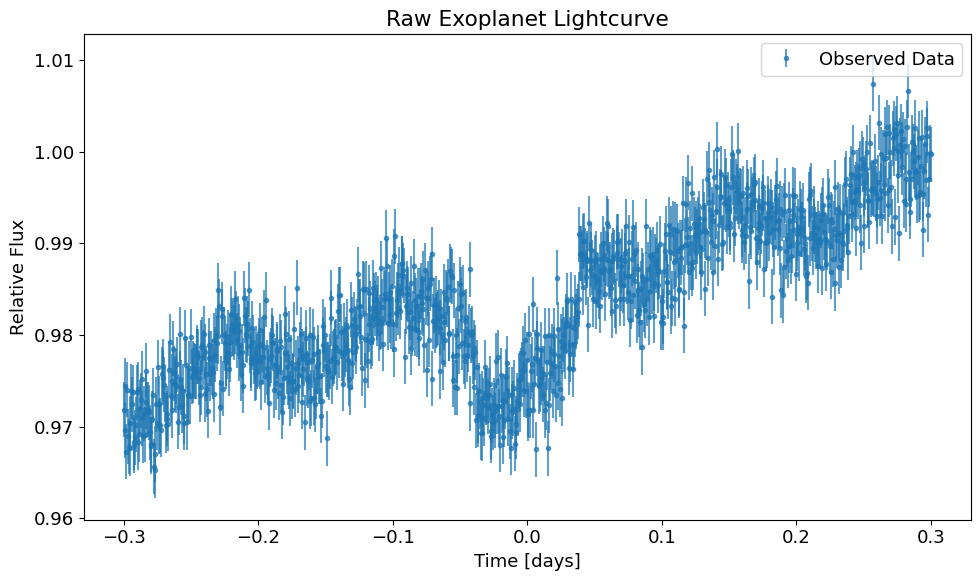

In [19]:
#Initial Lightcurve Plot
plt.figure()

plt.errorbar(time,
    flux,
    yerr=sigma_flux,
    fmt='.',
    alpha=0.7,
    label='Observed Data')

plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.title("Raw Exoplanet Lightcurve")
plt.legend()

plt.tight_layout()
plt.savefig("raw_lightcurve.pdf")

plt.show()

In [20]:
def artifact_model(t, c0, m, A, f, phi):
    """
    c0   : baseline offset
    m    : linear slope
    A    : oscillation amplitude
    f    : frequency (cycles/day)
    phi  : phase
    """
    return (c0 + m*t) + (A*np.sin(2*np.pi*f*t + phi))

In [21]:
#initial parameter guesses
c0_guess = np.mean(flux)
m_guess = 0.0
A_guess = (np.max(flux) - np.min(flux))/4
f_guess = 5.0
phi_guess = 0
p0 = [c0_guess, m_guess, A_guess, f_guess, phi_guess]

In [22]:
popt, pcov = curve_fit(
    artifact_model,
    time,
    flux,
    p0=p0,
    sigma=np.full(len(flux), sigma_flux),
    absolute_sigma=True,
    maxfev=100000
)

perr = np.sqrt(np.diag(pcov))

In [23]:
names = [
    "Offset c0",
    "Slope m",
    "Amplitude A",
    "Frequency f",
    "Phase phi"
]

print("Best-fit parameters:\n")

for n, val, err in zip(names, popt, perr):
    print(f"{n:15s} = {val:.6f} ± {err:.6f}")

artifact_fit = artifact_model(time, *popt)

Best-fit parameters:

Offset c0       = 0.983517 ± 0.000096
Slope m         = 0.041031 ± 0.000552
Amplitude A     = 0.002329 ± 0.000134
Frequency f     = 5.629304 ± 0.055529
Phase phi       = -1.867806 ± 0.058602


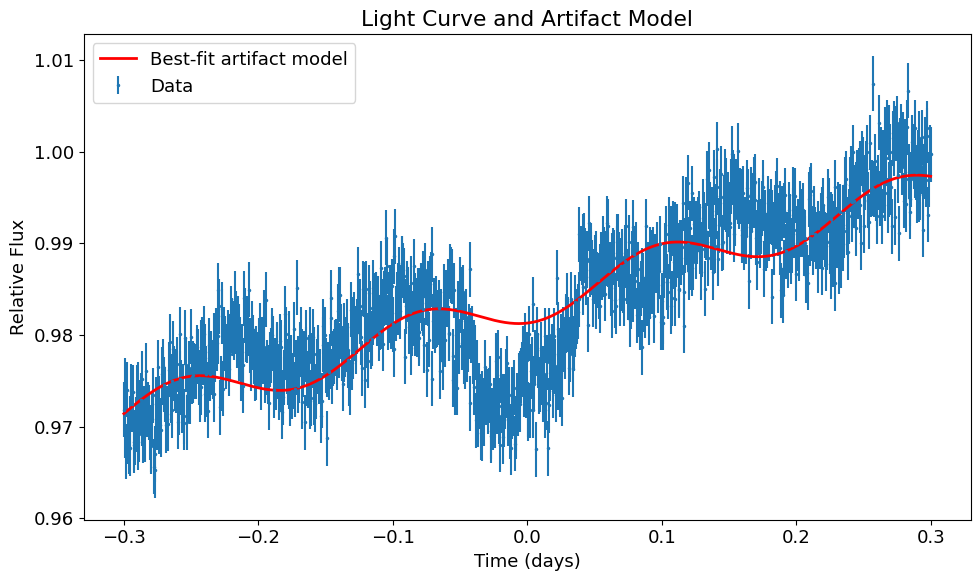

In [24]:
#plot raw data and model
plt.figure(figsize=(10,6))

plt.errorbar(
    time,
    flux,
    yerr=sigma_flux,
    fmt='.',
    ms=3,
    label='Data'
)

plt.plot(
    time,
    artifact_fit,
    'r',
    lw=2,
    label='Best-fit artifact model'
)

plt.xlabel("Time (days)")
plt.ylabel("Relative Flux")
plt.title("Light Curve and Artifact Model")
plt.legend()

plt.tight_layout()
plt.savefig("artifact_fit.pdf")
plt.show()

#remove artifacts
clean_flux = flux / artifact_fit
clean_flux /= np.median(clean_flux)

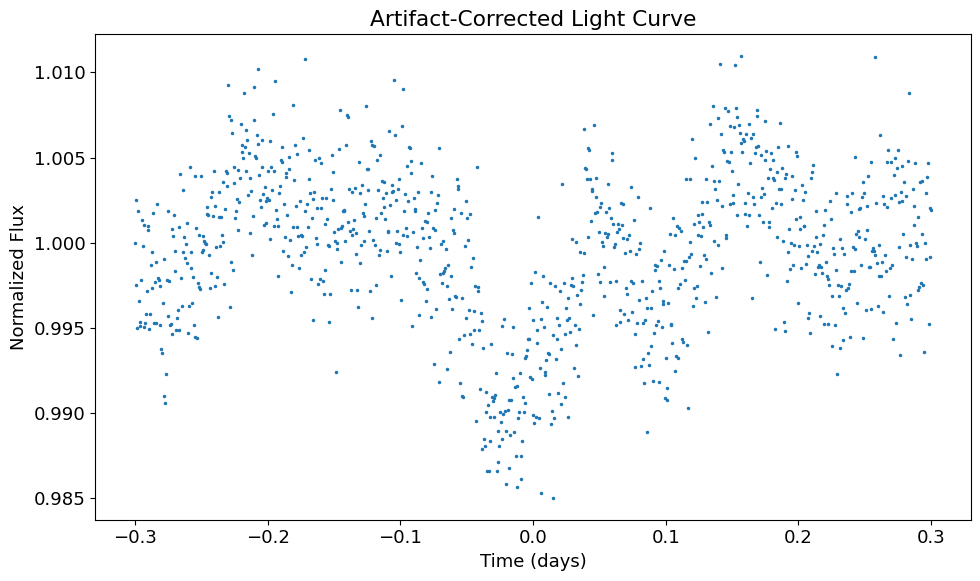

In [25]:
#plot cleaned light curve
plt.figure(figsize=(10,6))

plt.plot(
    time,
    clean_flux,
    '.',
    ms=3
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.title("Artifact-Corrected Light Curve")

plt.tight_layout()
plt.savefig("cleaned_lightcurve.pdf")
plt.show()

In [26]:
#Smooth the cleaned light curve using a moving median
from scipy.ndimage import median_filter
window = 31
smooth_flux = median_filter(
    clean_flux,
    size=window,
    mode='nearest'
)

In [ ]:
#Assume transit is near the middle of the dataset.
#Exclude central 20% when estimating baseline.

N = len(clean_flux)

exclude_start = int(0.40 * N)
exclude_end   = int(0.60 * N)

out_of_transit = np.concatenate([
    clean_flux[:exclude_start],
    clean_flux[exclude_end:]
])

baseline_flux = np.median(out_of_transit)

print(f"Baseline flux = {baseline_flux:.6f}")

In [ ]:
#Find significant departures from baseline

sigma_flux = 0.003
threshold = baseline_flux - 2*sigma_flux
transit_mask = smooth_flux < threshold
indices = np.where(transit_mask)[0]
groups = np.split(
    indices,
    np.where(np.diff(indices) > 1)[0] + 1
)

transit_group = max(groups, key=len)

start_idx = transit_group[0]
end_idx = transit_group[-1]

t_start = time[start_idx]
t_end = time[end_idx]

duration = t_end - t_start

print(f"Transit start = {t_start:.6f} days")
print(f"Transit end   = {t_end:.6f} days")
print(f"Duration      = {duration:.6f} days")

In [ ]:
#Determining transit depth

inside_transit = (
    (time >= t_start)
    &
    (time <= t_end)
)

transit_flux = np.median(
    clean_flux[inside_transit]
)

depth = baseline_flux - transit_flux

print(f"Transit flux level = {transit_flux:.6f}")
print(f"Transit depth      = {depth:.6f}")

In [ ]:
#Planet radius

R_star = 1.0
R_planet = np.sqrt(depth) * R_star
Rsun_to_Rearth = 109.1
R_planet_earth = R_planet * Rsun_to_Rearth

print(f"Planet radius = {R_planet:.6f} R_sun")
print(f"Planet radius = {R_planet_earth:.2f} R_earth")

In [ ]:
# Plot transit region
plt.figure(figsize=(10,6))
plt.plot(time, clean_flux, '.', ms=3, label='clean_data')
plt.plot(time, smooth_flux,'r',lw=2,label='Moving Median')
plt.axvline(t_start, color='r', ls='--',
            label='Transit Start')
plt.axvline(t_end, color='g', ls='--',
            label='Transit End')
plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.title("Transit Identification")
plt.legend()
plt.tight_layout()
plt.savefig("transit_region.pdf")
plt.show()